In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
np.random.seed(42)

n = 100
mean1 = [1, 1]
mean2 = [-1, -1]
mean3 = [1, -1]
mean4 = [-1, 1]

cov = [[1, 0], [0, 1]]

X1 = np.random.multivariate_normal(mean1, cov, n)
X2 = np.random.multivariate_normal(mean2, cov, n)
X3 = np.random.multivariate_normal(mean3, cov, n)
X4 = np.random.multivariate_normal(mean4, cov, n)

X = np.vstack([X1, X2, X3, X4])

# Labels
y = np.array([1]*n + [1]*n + [-1]*n + [-1]*n)

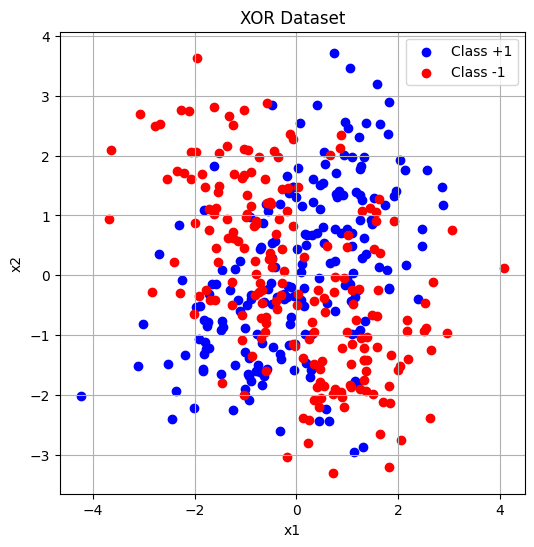

In [3]:
plt.figure(figsize=(6,6))

plt.scatter(X[y==1][:,0], X[y==1][:,1], color='blue', label='Class +1')
plt.scatter(X[y==-1][:,0], X[y==-1][:,1], color='red', label='Class -1')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('XOR Dataset')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
def linear_kernel(X, Z):
    return X @ Z.T

def polynomial_kernel(X, Z, degree=2):
    return (X @ Z.T + 1) ** degree

def rbf_kernel(X, Z, gamma=0.5):
    X_norm = np.sum(X**2, axis=1).reshape(-1,1)
    Z_norm = np.sum(Z**2, axis=1).reshape(1,-1)
    dist = X_norm + Z_norm - 2 * (X @ Z.T)
    return np.exp(-gamma * dist)

In [5]:
X_small = X[:8]

K_linear = linear_kernel(X_small, X_small)
K_poly = polynomial_kernel(X_small, X_small)
K_rbf = rbf_kernel(X_small, X_small)

print("Linear Kernel Matrix:\n", np.round(K_linear, 2))
print("\nPolynomial Kernel Matrix:\n", np.round(K_poly, 2))
print("\nRBF Kernel Matrix:\n", np.round(K_rbf, 2))

Linear Kernel Matrix:
 [[ 2.98  4.64  1.81  5.38  2.12  1.26  1.07 -0.71]
 [ 4.64  9.08  3.19  8.71  4.77  2.23 -0.26 -0.09]
 [ 1.81  3.19  1.17  3.33  1.59  0.82  0.25 -0.22]
 [ 5.38  8.71  3.33  9.78  4.09  2.33  1.59 -1.1 ]
 [ 2.12  4.77  1.59  4.09  2.66  1.11 -0.75  0.29]
 [ 1.26  2.23  0.82  2.33  1.11  0.57  0.18 -0.16]
 [ 1.07 -0.26  0.25  1.59 -0.75  0.18  2.38 -1.3 ]
 [-0.71 -0.09 -0.22 -1.1   0.29 -0.16 -1.3   0.72]]

Polynomial Kernel Matrix:
 [[1.5860e+01 3.1810e+01 7.8700e+00 4.0750e+01 9.7600e+00 5.1200e+00
  4.2900e+00 9.0000e-02]
 [3.1810e+01 1.0162e+02 1.7590e+01 9.4270e+01 3.3250e+01 1.0450e+01
  5.5000e-01 8.3000e-01]
 [7.8700e+00 1.7590e+01 4.7200e+00 1.8740e+01 6.7000e+00 3.3100e+00
  1.5700e+00 6.1000e-01]
 [4.0750e+01 9.4270e+01 1.8740e+01 1.1613e+02 2.5960e+01 1.1080e+01
  6.7000e+00 1.0000e-02]
 [9.7600e+00 3.3250e+01 6.7000e+00 2.5960e+01 1.3400e+01 4.4500e+00
  6.0000e-02 1.6700e+00]
 [5.1200e+00 1.0450e+01 3.3100e+00 1.1080e+01 4.4500e+00 2.4800e+00
  1.390

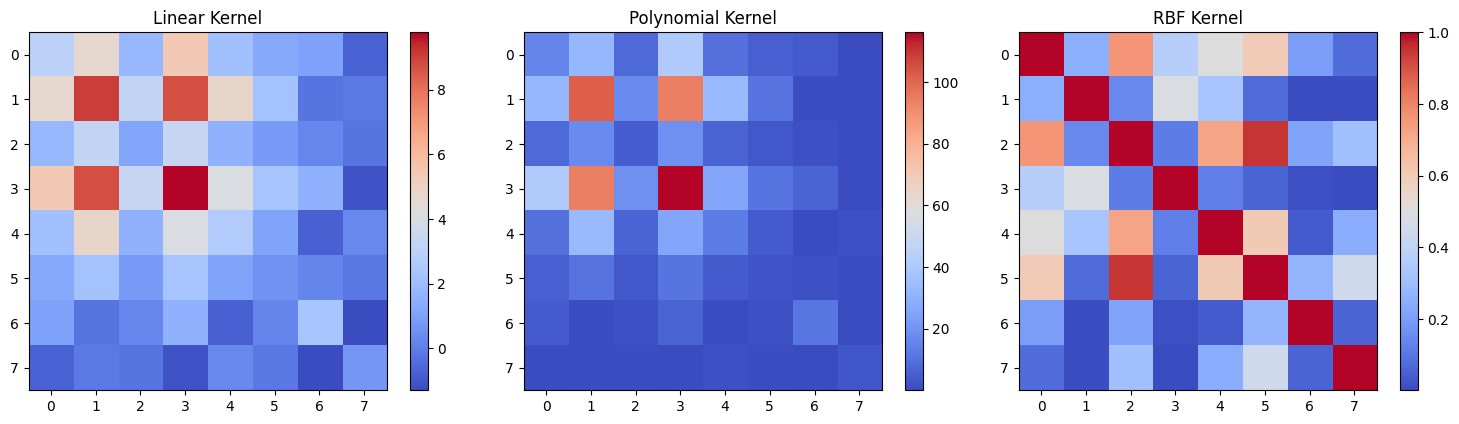

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

kernels = [K_linear, K_poly, K_rbf]
titles = ["Linear Kernel", "Polynomial Kernel", "RBF Kernel"]

for i in range(3):
    im = axes[i].imshow(kernels[i], cmap='coolwarm')
    axes[i].set_title(titles[i])
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()

In [7]:
def feature_map(X):
    x1 = X[:,0]
    x2 = X[:,1]
    
    phi1 = x1**2
    phi2 = np.sqrt(2) * x1 * x2
    phi3 = x2**2
    
    return np.vstack([phi1, phi2, phi3]).T

X_transformed = feature_map(X)

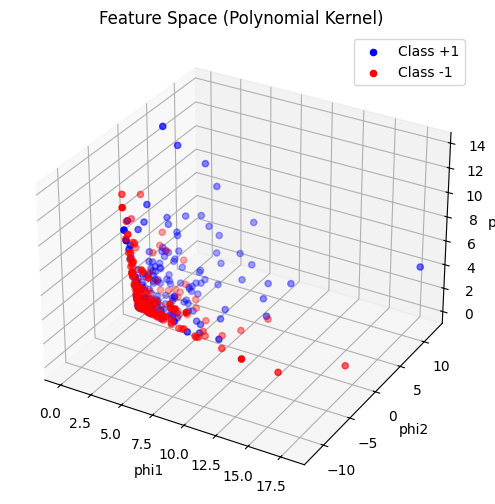

In [8]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_transformed[y==1][:,0],
           X_transformed[y==1][:,1],
           X_transformed[y==1][:,2],
           color='blue', label='Class +1')

ax.scatter(X_transformed[y==-1][:,0],
           X_transformed[y==-1][:,1],
           X_transformed[y==-1][:,2],
           color='red', label='Class -1')

ax.set_xlabel('phi1')
ax.set_ylabel('phi2')
ax.set_zlabel('phi3')
ax.set_title('Feature Space (Polynomial Kernel)')
ax.legend()

plt.show()